# Grammar Scoring Engine

## Overview
This notebook builds a pipeline to score spoken audio samples based on grammatical quality using a hybrid acoustic and semantic feature extraction approach.

## Approach
- **Audio Transcription:** OpenAI Whisper large-v3 (via faster-whisper) on 409 training + 197 test samples
- **Hybrid Feature Extraction:**
  - Whisper encoder embeddings (1280-dim acoustic features)
  - Handcrafted signal features: MFCC, Zero Crossing Rate, RMS energy (30-dim)
  - Semantic text embeddings from DeBERTa-v3-base CLS token (768-dim)
  - Combined feature vector: 2078-dim per sample
- **Models:**
  - XGBoost regressor tuned with Optuna (50 trials)
  - Stacking ensemble: LightGBM + Ridge, with RidgeCV to combine their predictions, both tuned with Optuna (20 trials each)
- **Training:**
  - 5-fold Cross-Validation for both XGBoost and stacking ensemble
  - StandardScaler applied per fold to prevent data leakage
- **Inference:** XGBoost and stacker predictions averaged and clipped to range 1–5

## Results
- Stacker OOF RMSE: 0.5438
- XGBoost OOF RMSE: 0.5559
- **Kaggle Leaderboard RMSE:** 0.47

## Note
Initially I explored fine-tuning DeBERTa-v3-base directly on transcripts for regression, achieving a OOF RMSE of **0.57** and a Kaggle Leaderboard RMSE of **0.53**. However, I realized that grammar scoring depends heavily on acoustic signals that text alone cannot capture. For example, fluency, hesitations and other speech features. This made me shift to a the following hybrid feature extraction approach, which improved performance.

## 1. Dependencies

In [3]:
!pip install -q openai-whisper kaggle scikit-learn pandas numpy matplotlib seaborn transformers accelerate datasets optuna faster-whisper

## 2. Imports and Configuration

In [4]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

import pandas as pd
import numpy as np
import whisper
from tqdm import tqdm
import os
import torch
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModel,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from xgboost import XGBRegressor
from sentence_transformers import SentenceTransformer
from faster_whisper import WhisperModel
import warnings
warnings.filterwarnings('ignore')

Saving kaggle.json to kaggle.json


## 3. Data Loading

In [5]:
!kaggle competitions download -c shl-intern-hiring-assessment-2025
!unzip -q shl-intern-hiring-assessment-2025.zip

 88% 1.09G/1.23G [00:00<00:00, 1.59GB/s]
100% 1.23G/1.23G [00:00<00:00, 1.45GB/s]


In [6]:
train_df = pd.read_csv('dataset/csvs/train.csv')
test_df = pd.read_csv('dataset/csvs/test.csv')
print(len(train_df), len(test_df))
print(train_df['label'].describe())

409 197
count    409.000000
mean       2.910758
std        0.766953
min        1.000000
25%        2.500000
50%        3.000000
75%        3.000000
max        5.000000
Name: label, dtype: float64


## 4. Audio Transcription
Transcribing all audio files using Whisper large-v3 via faster-whisper for significantly faster inference without any loss in transcription quality. Transcripts are saved to CSV to avoid recomputation.

In [ ]:
fw_model = WhisperModel("large-v3", device="cuda", compute_type="float16")

def transcribe_fast(filename, audio_dir):
    try:
        segments, _ = fw_model.transcribe(f"{audio_dir}/{filename}.wav")
        return " ".join([s.text for s in segments]).strip()
    except:
        return ""

train_df['transcript'] = [
    transcribe_fast(fn, "dataset/audios/train")
    for fn in tqdm(train_df['filename'])
]
test_df['transcript'] = [
    transcribe_fast(fn, "dataset/audios/test")
    for fn in tqdm(test_df['filename'])
]

print(train_df['transcript'].str.len().mean())       #just a simple small check :)

del fw_model
torch.cuda.empty_cache()
gc.collect()

train_df.to_csv('train_with_transcripts.csv', index=False)
test_df.to_csv('test_with_transcripts.csv', index=False)

In [7]:
train_df = pd.read_csv('train_with_transcripts.csv')    #loading the saved transcripts in case you already have them to avoid recomputation
test_df = pd.read_csv('test_with_transcripts.csv')

## 5. Hybrid Feature Extraction

Grammar scoring depends on both **acoustic delivery** and **linguistic correctness**. A text-only approach misses fluency, hesitations, and other audio components all of which correlate with grammar scores. This motivates combining these three feature types:

- **Whisper Encoder Embeddings:** Deep acoustic representations from the Whisper large-v3 encoder. Mean pooling over the time dimension produces a 1280-dim vector capturing speech patterns.
- **Handcrafted Signal Features:** MFCC coefficients, Zero Crossing Rate, and RMS energy computed via Librosa. These stable, low-dimensional statistics improve robustness on small datasets.
- **DeBERTa Text Embeddings:** CLS token embeddings from DeBERTa-v3-base applied to transcripts. Captures grammatical structure, sentence coherence, and vocabulary usage.

All features are concatenated into a single 2078-dim vector per sample.

In [8]:
text_tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base")
text_model = AutoModel.from_pretrained("microsoft/deberta-v3-base").cuda()
text_model.eval()

def extract_deberta_embedding(transcript):
    try:
        inputs = text_tokenizer(str(transcript), return_tensors="pt", truncation=True, max_length=512, padding=True)
        inputs = {k: v.cuda() for k, v in inputs.items()}
        with torch.no_grad():
            outputs = text_model(**inputs)
        return outputs.last_hidden_state[:, 0, :].squeeze().cpu().numpy()
    except:
        return np.zeros(768)

whisper_extractor = whisper.load_model("large-v3", device="cuda")

def extract_whisper_embeddings(audio_path):
    try:
        audio = whisper.load_audio(audio_path)
        audio = whisper.pad_or_trim(audio)
        mel = whisper.log_mel_spectrogram(audio, n_mels=whisper_extractor.dims.n_mels).to("cuda")
        with torch.no_grad():
            encoded = whisper_extractor.encoder(mel.unsqueeze(0))
        return encoded.squeeze(0).mean(dim=0).cpu().numpy()
    except:
        return np.zeros(1280)

def extract_handcrafted(audio_path):
    try:
        import librosa
        y, sr = librosa.load(audio_path, sr=16000)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        zcr = librosa.feature.zero_crossing_rate(y)[0]
        rms = librosa.feature.rms(y=y)[0]
        return np.concatenate([
            np.mean(mfcc, axis=1), np.std(mfcc, axis=1),
            [np.mean(zcr), np.std(zcr)],
            [np.mean(rms), np.std(rms)]
        ])
    except:
        return np.zeros(30)

train_whisper = np.array([extract_whisper_embeddings(f"dataset/audios/train/{fn}.wav") for fn in tqdm(train_df['filename'])])
train_handcrafted = np.array([extract_handcrafted(f"dataset/audios/train/{fn}.wav") for fn in tqdm(train_df['filename'])])
train_text = np.array([extract_deberta_embedding(t) for t in tqdm(train_df['transcript'])])

test_whisper = np.array([extract_whisper_embeddings(f"dataset/audios/test/{fn}.wav") for fn in tqdm(test_df['filename'])])
test_handcrafted = np.array([extract_handcrafted(f"dataset/audios/test/{fn}.wav") for fn in tqdm(test_df['filename'])])
test_text = np.array([extract_deberta_embedding(t) for t in tqdm(test_df['transcript'])])

X_train_full = np.hstack([train_whisper, train_handcrafted, train_text])
X_test_full = np.hstack([test_whisper, test_handcrafted, test_text])
print(X_train_full.shape)

del whisper_extractor, text_model
torch.cuda.empty_cache()
gc.collect()

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
  6%|██▏                                    | 163M/2.

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

100%|██████████████████████████████████████| 2.88G/2.88G [00:12<00:00, 241MiB/s]
100%|██████████| 197/197 [00:05<00:00, 36.15it/s]


(409, 2078)


117571

## 6. Hyperparameter Optimization
Using Optuna for Bayesian hyperparameter search across XGBoost, LightGBM, and Ridge. Each model is evaluated using 5-fold cross-validation with RMSE as the objective metric.

In [10]:
import optuna
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 600),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'subsample': trial.suggest_float('subsample', 0.4, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.9),
        'min_child_weight': trial.suggest_int('min_child_weight', 2, 8),
        'device': 'cuda',
        'verbosity': 0,
        'random_state': 42
    }
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmses = []
    for train_idx, val_idx in kf.split(X_train_full):
        X_tr = StandardScaler().fit_transform(X_train_full[train_idx])
        X_val = StandardScaler().fit_transform(X_train_full[val_idx])
        y_tr = train_df['label'].values[train_idx]
        y_val = train_df['label'].values[val_idx]
        model = XGBRegressor(**params)
        model.fit(X_tr, y_tr)
        rmses.append(np.sqrt(mean_squared_error(y_val, model.predict(X_val))))
    return np.mean(rmses)

study = optuna.create_study(direction='minimize')
optuna.logging.set_verbosity(optuna.logging.INFO)
study.optimize(objective, n_trials=50)
print(f"Best RMSE = {study.best_value:.4f}")
print(f"Best params = {study.best_params}")

[I 2026-03-05 13:54:44,922] A new study created in memory with name: no-name-0aac665e-842c-4b00-b735-06dc0b4ccf1b
[I 2026-03-05 13:54:50,039] Trial 0 finished with value: 0.5917501255396982 and parameters: {'n_estimators': 564, 'learning_rate': 0.07990491460748814, 'max_depth': 5, 'subsample': 0.6403193507971779, 'colsample_bytree': 0.718668977358067, 'min_child_weight': 4}. Best is trial 0 with value: 0.5917501255396982.
[I 2026-03-05 13:54:52,231] Trial 1 finished with value: 0.5876227128625333 and parameters: {'n_estimators': 558, 'learning_rate': 0.03391644614117491, 'max_depth': 2, 'subsample': 0.8346577724528423, 'colsample_bytree': 0.6300614952807255, 'min_child_weight': 8}. Best is trial 1 with value: 0.5876227128625333.
[I 2026-03-05 13:54:53,812] Trial 2 finished with value: 0.5875974481050646 and parameters: {'n_estimators': 372, 'learning_rate': 0.03323106895667199, 'max_depth': 2, 'subsample': 0.6678942295876205, 'colsample_bytree': 0.629157158617257, 'min_child_weight': 4

Best RMSE = 0.5661
Best params = {'n_estimators': 535, 'learning_rate': 0.05613234464745337, 'max_depth': 3, 'subsample': 0.4452286459795424, 'colsample_bytree': 0.5932663609239521, 'min_child_weight': 4}


## 7. XGBoost Training
5-fold cross-validation using the best hyperparameters found by Optuna. StandardScaler is fit only on training folds to prevent data leakage into validation.

In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(train_df))
test_preds = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_full)):
    print(f"Fold {fold+1}/5")

    X_tr, X_val = X_train_full[train_idx], X_train_full[val_idx]
    y_tr, y_val = train_df['label'].values[train_idx], train_df['label'].values[val_idx]

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)
    X_te = scaler.transform(X_test_full)

    model = XGBRegressor(
        **study.best_params,
        device='cuda',
        verbosity=0,
        random_state=42
    )
    model.fit(X_tr, y_tr)

    val_preds = model.predict(X_val)
    oof_preds[val_idx] = val_preds
    test_preds.append(model.predict(X_te))

    fold_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    print(f"Fold {fold+1} RMSE: {fold_rmse:.4f}")

final_rmse = np.sqrt(mean_squared_error(train_df['label'], oof_preds))
print(f"\nOOF RMSE: {final_rmse:.4f}")

Fold 1/5
Fold 1 RMSE: 0.5474
Fold 2/5
Fold 2 RMSE: 0.5585
Fold 3/5
Fold 3 RMSE: 0.5458
Fold 4/5
Fold 4 RMSE: 0.5562
Fold 5/5
Fold 5 RMSE: 0.5713

OOF RMSE: 0.5559


In [12]:
!pip install -q lightgbm

In [13]:
import lightgbm as lgb
from sklearn.linear_model import Ridge

def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 600),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'subsample': trial.suggest_float('subsample', 0.4, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.9),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 30),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'device': 'gpu',
        'verbosity': -1,
        'random_state': 42
    }
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmses = []
    for train_idx, val_idx in kf.split(X_train_full):
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_train_full[train_idx])
        X_val = scaler.transform(X_train_full[val_idx])
        y_tr = train_df['label'].values[train_idx]
        y_val = train_df['label'].values[val_idx]
        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr)
        rmses.append(np.sqrt(mean_squared_error(y_val, model.predict(X_val))))
    return np.mean(rmses)

def objective_ridge(trial):
    alpha = trial.suggest_float('alpha', 0.01, 100.0, log=True)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmses = []
    for train_idx, val_idx in kf.split(X_train_full):
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_train_full[train_idx])
        X_val = scaler.transform(X_train_full[val_idx])
        y_tr = train_df['label'].values[train_idx]
        y_val = train_df['label'].values[val_idx]
        model = Ridge(alpha=alpha)
        model.fit(X_tr, y_tr)
        rmses.append(np.sqrt(mean_squared_error(y_val, model.predict(X_val))))
    return np.mean(rmses)

study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgb, n_trials=20)
print(f"Best LightGBM RMSE: {study_lgb.best_value:.4f}")

study_ridge = optuna.create_study(direction='minimize')
study_ridge.optimize(objective_ridge, n_trials=20)
print(f"Best Ridge RMSE: {study_ridge.best_value:.4f}")

[I 2026-03-05 13:57:34,416] A new study created in memory with name: no-name-148d53bf-04e1-4def-a571-429a2c61fef8
[I 2026-03-05 13:58:15,456] Trial 0 finished with value: 0.582345973213821 and parameters: {'n_estimators': 535, 'learning_rate': 0.02733473001354326, 'max_depth': 5, 'subsample': 0.5773363186375441, 'colsample_bytree': 0.7927364688315981, 'min_child_samples': 8, 'reg_alpha': 0.06633880775484152, 'reg_lambda': 0.020587912350071878}. Best is trial 0 with value: 0.582345973213821.
[I 2026-03-05 13:58:26,395] Trial 1 finished with value: 0.5959726351136451 and parameters: {'n_estimators': 233, 'learning_rate': 0.010055610701634089, 'max_depth': 5, 'subsample': 0.4291603521519765, 'colsample_bytree': 0.5186818176297406, 'min_child_samples': 16, 'reg_alpha': 0.363709801007591, 'reg_lambda': 2.4666476579438585}. Best is trial 0 with value: 0.582345973213821.
[I 2026-03-05 13:58:38,441] Trial 2 finished with value: 0.5727491915892269 and parameters: {'n_estimators': 395, 'learning

Best LightGBM RMSE: 0.5634


[I 2026-03-05 14:02:25,247] Trial 0 finished with value: 0.6147008487091516 and parameters: {'alpha': 0.016681002323470952}. Best is trial 0 with value: 0.6147008487091516.
[I 2026-03-05 14:02:25,658] Trial 1 finished with value: 0.6133042811250619 and parameters: {'alpha': 1.8405138963768788}. Best is trial 1 with value: 0.6133042811250619.
[I 2026-03-05 14:02:26,091] Trial 2 finished with value: 0.6146901377066079 and parameters: {'alpha': 0.030280259020204224}. Best is trial 1 with value: 0.6133042811250619.
[I 2026-03-05 14:02:26,438] Trial 3 finished with value: 0.6146623947227277 and parameters: {'alpha': 0.06553208175470854}. Best is trial 1 with value: 0.6133042811250619.
[I 2026-03-05 14:02:26,906] Trial 4 finished with value: 0.614390731236641 and parameters: {'alpha': 0.41284849644192567}. Best is trial 1 with value: 0.6133042811250619.
[I 2026-03-05 14:02:27,328] Trial 5 finished with value: 0.6147040414068576 and parameters: {'alpha': 0.012628543190738825}. Best is trial 1

Best Ridge RMSE: 0.5767


## 8. Stacking Ensemble
A stacking ensemble combining LightGBM and Ridge regression with a RidgeCV meta-learner. Each base model is tuned independently via Optuna. The ensemble is trained and evaluated using the same 5-fold CV scheme to ensure honest OOF estimates.

In [14]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline

kf = KFold(n_splits=5, shuffle=True, random_state=42)
stacker_oof = np.zeros(len(train_df))
stacker_test_preds = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_full)):
    print(f"Stacker Fold {fold+1}/5")

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train_full[train_idx])
    X_val = scaler.transform(X_train_full[val_idx])
    X_te = scaler.transform(X_test_full)

    y_tr = train_df['label'].values[train_idx]
    y_val = train_df['label'].values[val_idx]

    best_lgb = lgb.LGBMRegressor(
        **study_lgb.best_params,
        device='gpu', verbosity=-1, random_state=42
    )
    best_ridge = make_pipeline(
        StandardScaler(),
        Ridge(**study_ridge.best_params)
    )

    stacker = StackingRegressor(
        estimators=[('lgbm', best_lgb), ('ridge', best_ridge)],
        final_estimator=RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0]),
        cv=5, n_jobs=1
    )

    stacker.fit(X_tr, y_tr)
    stacker_oof[val_idx] = stacker.predict(X_val)
    stacker_test_preds.append(stacker.predict(X_te))

stacker_rmse = np.sqrt(mean_squared_error(train_df['label'], stacker_oof))
print(f"Stacker OOF RMSE: {stacker_rmse:.4f}")

final_rmse = np.sqrt(mean_squared_error(train_df['label'], oof_preds))
print(f"XGBoost OOF RMSE: {final_rmse:.4f}")

Stacker Fold 1/5
Stacker Fold 2/5
Stacker Fold 3/5
Stacker Fold 4/5
Stacker Fold 5/5
Stacker OOF RMSE: 0.5438
XGBoost OOF RMSE: 0.5559


## 9. Final Predictions
Final test predictions are a weighted average of both models, clipped to the valid score range of 1–5.

In [15]:
final_preds = np.average([
    np.clip(np.mean(test_preds, axis=0), 1, 5),
    np.clip(np.mean(stacker_test_preds, axis=0), 1, 5)
], weights=[0.5, 0.5], axis=0)

submission = pd.DataFrame({
    'filename': test_df['filename'],
    'label': final_preds
})
submission.to_csv('submission.csv', index=False)
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. Visualizations

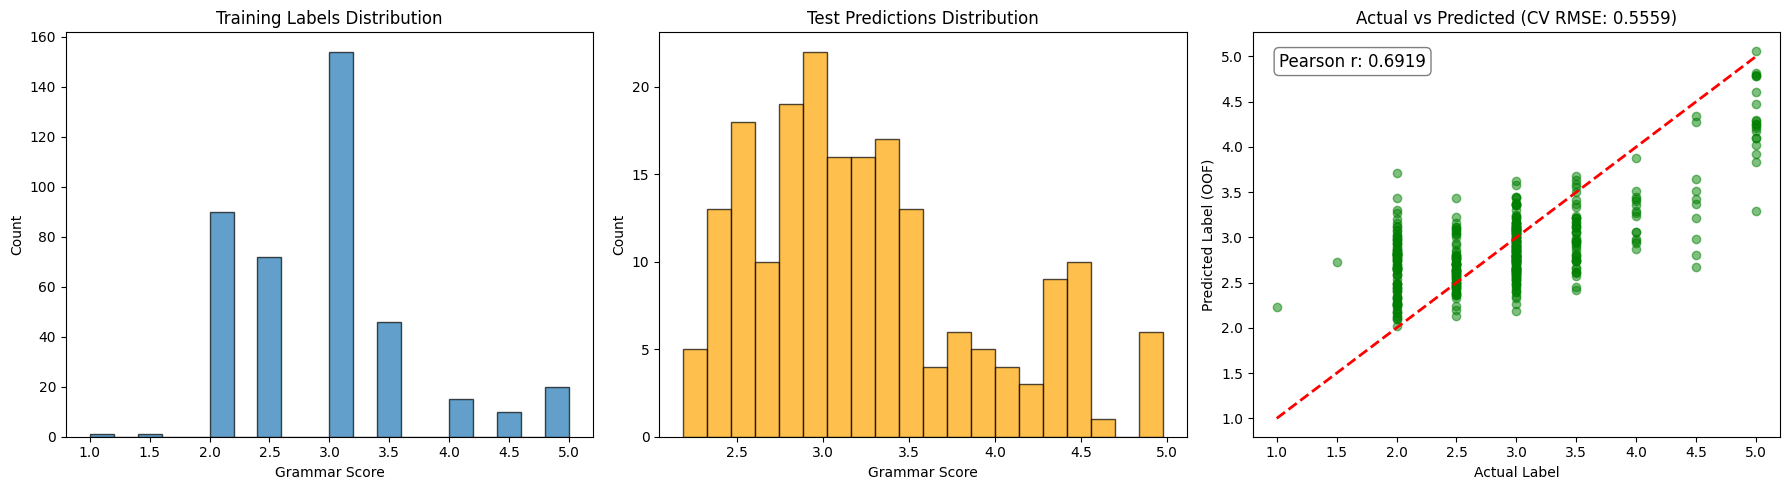

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(train_df['label'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title('Training Labels Distribution')
axes[0].set_xlabel('Grammar Score')
axes[0].set_ylabel('Count')

axes[1].hist(submission['label'], bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Test Predictions Distribution')
axes[1].set_xlabel('Grammar Score')
axes[1].set_ylabel('Count')

axes[2].scatter(train_df['label'], oof_preds, alpha=0.5, color='green')
axes[2].plot([1, 5], [1, 5], 'r--', lw=2)
axes[2].set_title(f'Actual vs Predicted (CV RMSE: {final_rmse:.4f})')
axes[2].set_xlabel('Actual Label')
axes[2].set_ylabel('Predicted Label (OOF)')

correlation, _ = pearsonr(train_df['label'], oof_preds)
axes[2].text(0.05, 0.95, f'Pearson r: {correlation:.4f}',
             transform=axes[2].transAxes, fontsize=12,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()